In [2]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import defaultdict

The degree for a directed weighted graph is defined as follows : total-degree = in-degree + out-degree <br>
<br>
Where the in-degree is defined as the sum of the weights of all the edges that are directed into the node and the out-degree is defined as the sum of the weights of all the edges that are directed out of the node <br>
<br>
For example, a node which has 2 edges directed into a node with edge weights 5 and -2 and 1 edge directed out of the node <br>
with edge weight 6 then the indegree will be 5 + (-2) = 3 and the outdegree will be 6 and consequently the total degree will be 3 + 6 = 9.


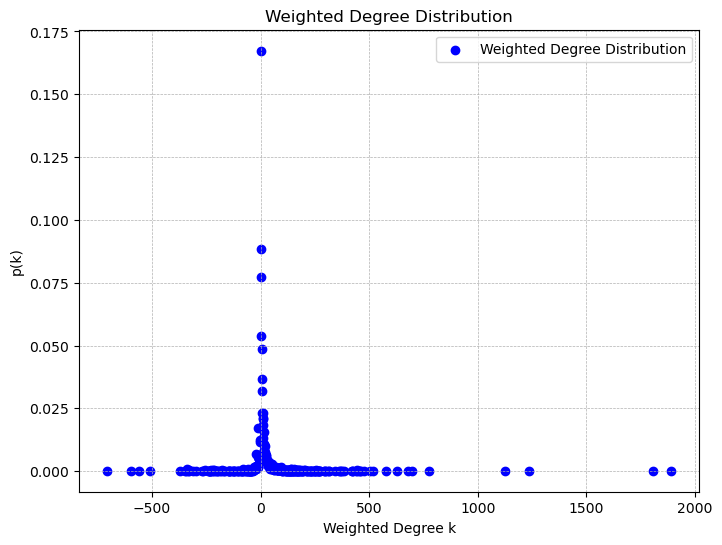

In [4]:
in_degree = {}
out_degree = {}
with open("soc-sign-bitcoinotc.csv", "r") as file:
    for line in file:
        components = line.strip().split(",")  
        src, dest, weight = map(int, components[:3])
        out_degree[src] = out_degree.get(src, 0) + weight
        in_degree[dest] = in_degree.get(dest, 0) + weight
total_degree = {}
all_nodes = set(in_degree.keys()).union(set(out_degree.keys()))

for node in all_nodes:
    in_deg = in_degree.get(node, 0)
    out_deg = out_degree.get(node, 0)
    total_degree[node] = in_deg + out_deg
    
def plot_weighted_degree_distribution(total_degree):
    degree_counts = Counter(total_degree.values())
    k_vals = np.array(list(degree_counts.keys())) 
    p_k = np.array(list(degree_counts.values())) / sum(degree_counts.values())
    plt.figure(figsize=(8, 6))
    plt.scatter(k_vals, p_k, marker='o', color='b', label="Weighted Degree Distribution")
    #plt.xscale("log")
    #plt.yscale("log")
    plt.xlabel("Weighted Degree k")
    plt.ylabel("p(k)")
    plt.title("Weighted Degree Distribution")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()
plot_weighted_degree_distribution(total_degree)

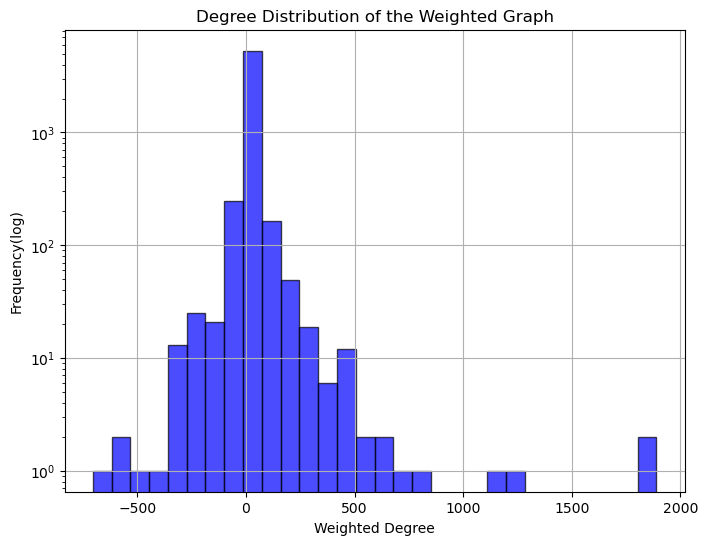

In [5]:
plt.figure(figsize=(8, 6))
plt.hist(total_degree.values(), bins=30, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Weighted Degree")
plt.yscale("log")
plt.ylabel("Frequency(log)")
plt.title("Degree Distribution of the Weighted Graph")
plt.grid(True)
plt.show()

The clustering coefficient for any node 'i' in a weighted directed graph is defined as follows : <br>
C_i = (2/k_i*(k_i - 1)) * sigma_j_k((w_i_j + w_i_k)/2) if there is a edge from i to j, i to k and j to k and summation is for all pairs of neighbour nodes j & k<br>
<br>
k_i -> total weighted degree of node 'i' <br>
w_i_j -> edge weight of edge from node i to neighbouring node j <br>
w_i_k -> edge weight of edge from node i to neighbouring node k <br>

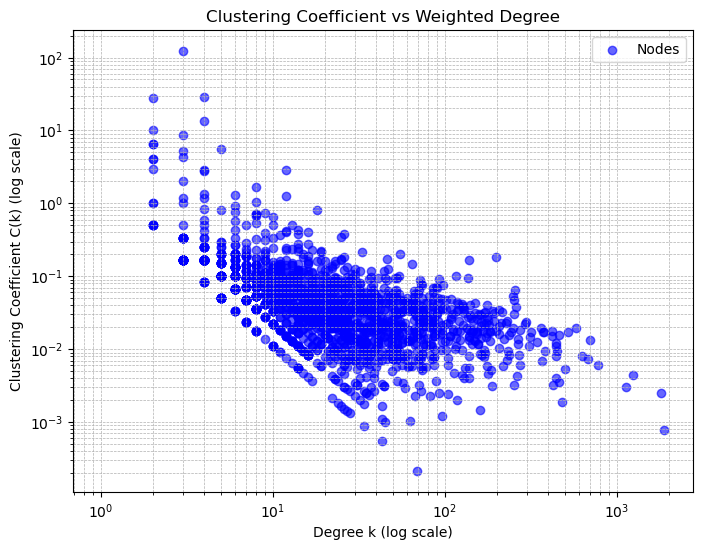

In [7]:
weights = defaultdict(lambda: defaultdict(int))
neighbors = defaultdict(set)

with open("soc-sign-bitcoinotc.csv", "r") as file:
    for line in file:
        components = line.strip().split(",")
        src, dest, weight = map(int, components[:3])
        weights[src][dest] = weight
        neighbors[src].add(dest)
        neighbors[dest].add(src)

clustering_coeffs = {}
for node in total_degree:
    if total_degree[node] < 2:
        clustering_coeffs[node] = 0.0
        continue
    
    sum_weights = 0
    neighbors_list = list(neighbors[node])

    for i in range(len(neighbors_list)):
        for j in range(i + 1, len(neighbors_list)):
            node_i, node_j = neighbors_list[i], neighbors_list[j]
            
            if node_j in weights[node_i]: 
                weight_ij = (weights[node].get(node_i, 0) + weights[node].get(node_j, 0)) / 2
                sum_weights += weight_ij
    
    k_total = total_degree[node]
    if k_total > 1:
        clustering_coeffs[node] = (2 * sum_weights) / (k_total * (k_total - 1))
    else:
        clustering_coeffs[node] = 0
        
degrees = list(total_degree.values())
clustering_values = list(clustering_coeffs.values())
plt.figure(figsize=(8, 6))
plt.scatter(degrees, clustering_values, alpha=0.6, color="b", label="Nodes")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("Clustering Coefficient C(k) (log scale)")
plt.title("Clustering Coefficient vs Weighted Degree")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()
